<a href="https://colab.research.google.com/github/Sandesh-Ghimire/Credit-Card-Default-final/blob/main/optimizedcode-collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

!pip install lime shap

import shap
from lime.lime_tabular import LimeTabularExplainer

import joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a1f193252c001bd6c2636a605f325461b05ed287ce1b55bbbb7667b20a3f29ea
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
#2. LOAD DATA
# ================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/default of credit card clients.xls', header=1)

df.rename(columns={"default payment next month": "default"}, inplace=True)
df.drop(columns=["ID"], inplace=True)

print(df.head())


Mounted at /content/drive
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default  

In [ ]:
# ================================
# FEATURE ENGINEERING
# ================================

# Total bill amount
df["TOTAL_BILL"] = df[[
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]].sum(axis=1)

# Total payment
df["TOTAL_PAY"] = df[[
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]].sum(axis=1)

# Payment ratio
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1)

# Average delay
df["AVG_DELAY"] = df[[
    "PAY_0","PAY_2","PAY_3",
    "PAY_4","PAY_5","PAY_6"
]].mean(axis=1)

In [ ]:
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (for LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

# Keep original data
X_train_res, y_train_res = X_train, y_train

# Compute imbalance weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("Class Distribution:", np.bincount(y_train))
print("Scale Pos Weight:", scale_pos_weight)

Class Distribution: [18691  5309]
Scale Pos Weight: 3.520625353173856


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import xgboost as xgb

# ================================
# XGBOOST + HYPERPARAMETER TUNING
# ================================

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

# Handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

grid = GridSearchCV(
    xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist'
    ),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Train with GridSearch
grid.fit(X_train_res, y_train_res)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ================================
# FINAL TRAINING (NO EARLY STOPPING)
# ================================

best_model.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
# 8. THRESHOLD TUNING
# ================================
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))

# FINAL THRESHOLD (SELECTED)
y_pred = (y_prob > 0.5).astype(int)



Threshold: 0.2
              precision    recall  f1-score   support

           0       0.96      0.15      0.26      4673
           1       0.25      0.98      0.39      1327

    accuracy                           0.33      6000
   macro avg       0.60      0.56      0.33      6000
weighted avg       0.80      0.33      0.29      6000


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.41      0.57      4673
           1       0.30      0.88      0.45      1327

    accuracy                           0.52      6000
   macro avg       0.61      0.65      0.51      6000
weighted avg       0.79      0.52      0.54      6000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.65      0.75      4673
           1       0.38      0.74      0.50      1327

    accuracy                           0.67      6000
   macro avg       0.64      0.70      0.63      6000
weighted avg       0.78   

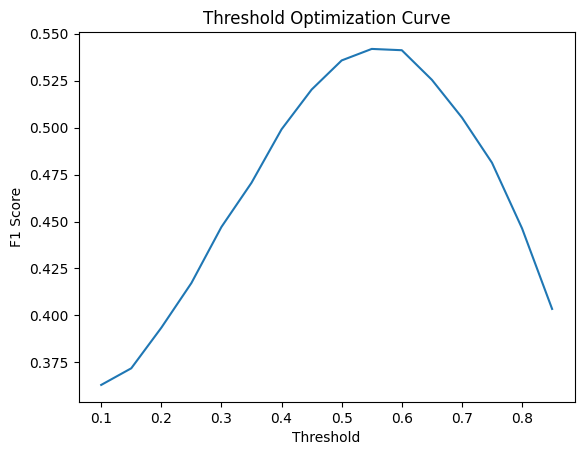

In [ ]:
# 8.1 THRESHOLD OPTIMIZATION GRAPH
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    preds = (y_prob > t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization Curve")
plt.show()

In [ ]:
# 9. MODEL EVALUATION
# ================================
print("\nFinal XGBoost Model")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))



Final XGBoost Model
Accuracy: 0.7611666666666667
ROC-AUC: 0.7800670239060317
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.47      0.62      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



In [ ]:
# ================================
# 9.1 MODEL COMPARISON TABLE
# ================================

# Logistic predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Random Forest predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGBoost already computed
# y_pred, y_prob

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob)
    ]
})

print(comparison)

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.807667  0.707683
1        Random Forest  0.814500  0.755428
2              XGBoost  0.761167  0.780067


In [ ]:
# 10. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3740  933]
 [ 500  827]]


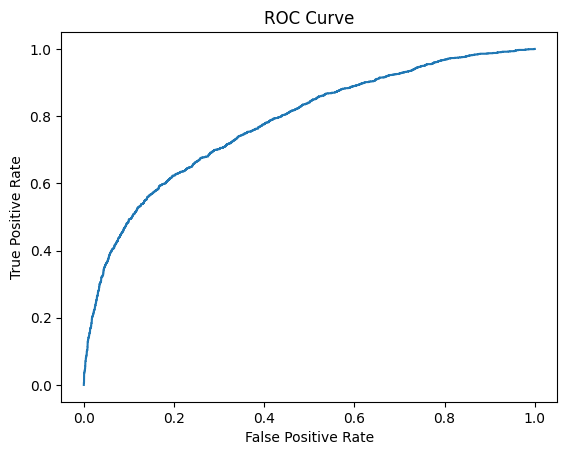

In [ ]:
# 11. ROC CURVE
# ================================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


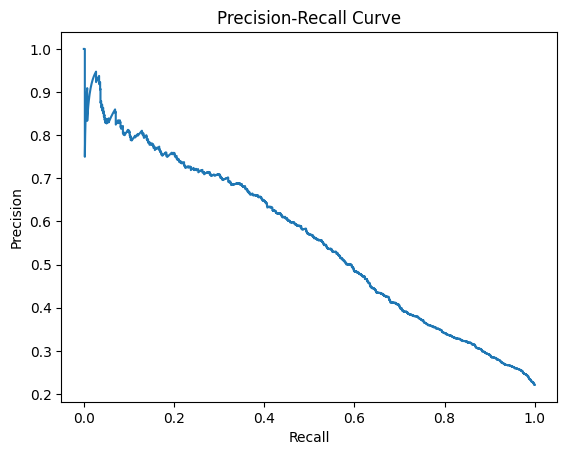

In [ ]:
# 12. PRECISION-RECALL CURVE
# ================================
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

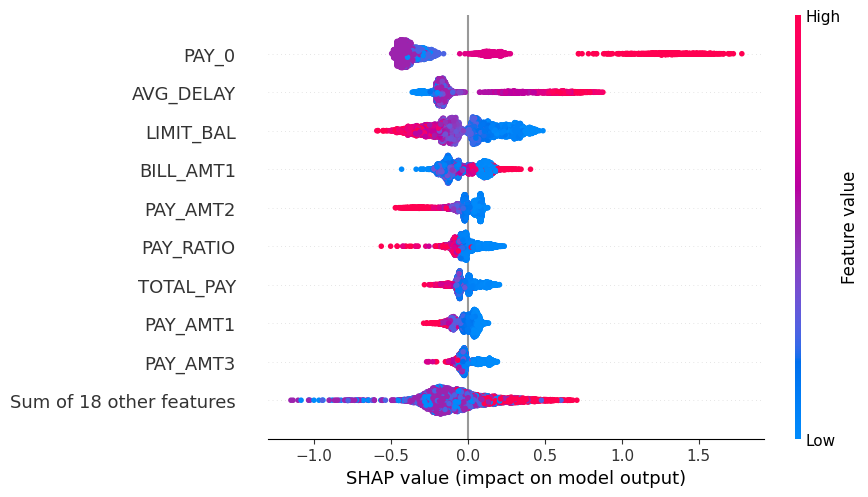

In [ ]:
# 13. SHAP (GLOBAL EXPLAINABILITY)
# ================================
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


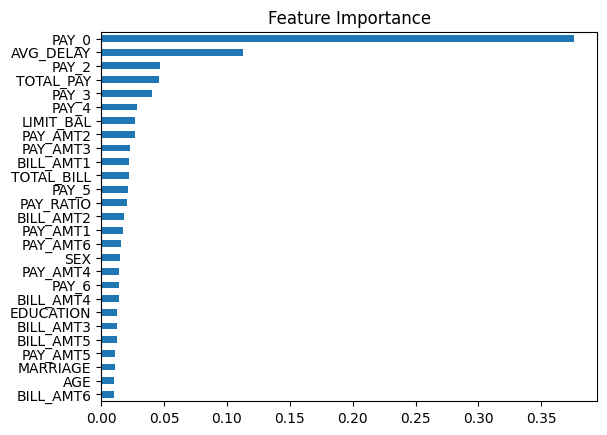

In [ ]:
# 14. FEATURE IMPORTANCE
# ================================
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


In [ ]:
# 15. LIME (LOCAL EXPLAINABILITY)
# ================================
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    best_model.predict_proba
)

exp.show_in_notebook()


In [ ]:
# 16. FAIRNESS ANALYSIS
# ================================
df_fair = X_test.copy()
df_fair["prediction"] = y_pred

male_rate = df_fair[df_fair["SEX"] == 1]["prediction"].mean()
female_rate = df_fair[df_fair["SEX"] == 2]["prediction"].mean()

print("Male Default Rate:", male_rate)
print("Female Default Rate:", female_rate)
print("Demographic Parity Difference:", abs(male_rate - female_rate))


Male Default Rate: 0.31848459616985847
Female Default Rate: 0.2765425236242357
Demographic Parity Difference: 0.041942072545622766


In [ ]:
# 17. DSS (RISK CLASSIFICATION)
# ================================
def risk_level(p):
    if p < 0.25:
        return "Low Risk"
    elif p < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

risk = [risk_level(p) for p in y_prob]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob,
    "Risk Level": risk
})

print(results.head())


   Actual  Probability   Risk Level
0       0     0.367584  Medium Risk
1       0     0.320105  Medium Risk
2       0     0.383001  Medium Risk
3       1     0.314945  Medium Risk
4       0     0.121613     Low Risk


In [ ]:
# 18. SAVE MODEL
# ================================
joblib.dump(best_model, "model.pkl")

['model.pkl']